# Chapter 53 — Domain and Range

> **Prerequisites:** ch051 (What is a Function?), ch026 (Real Numbers), ch038 (Floating-Point)
> 
> **You will learn:**
> - Precise definitions of domain, codomain, and range (image)
> - Natural domain vs restricted domain
> - How domain restrictions arise in computation (division, square roots, logs)
> - How to determine range analytically and computationally
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **domain** of a function f : A → B is the set A — all valid inputs.
The **codomain** is the set B — all *possible* outputs by declaration.
The **range** (or image) is `{f(x) : x ∈ A}` — all outputs that are *actually produced*.

The range is always a subset of the codomain, but they need not be equal.

**Natural domain:** the largest set on which a formula is defined without causing mathematical errors. For `f(x) = 1/x`, the natural domain is all real numbers except 0. For `f(x) = √x`, it is x ≥ 0.

**Restricted domain:** a subset of the natural domain, chosen deliberately. We might restrict f(x) = x² to x ≥ 0 to make it invertible.

**Common misconception:** Codomain and range are the same thing. They are not. f(x) = x² declared as f : ℝ → ℝ has codomain ℝ but range [0, ∞). The range is determined by the formula; the codomain is declared by the programmer or mathematician.

**Why it matters in programming:** Every time you call `np.log(x)` with x ≤ 0, or `1/x` with x = 0, you have violated the domain. NumPy returns `nan` or `inf` instead of raising an error — a silent failure. Knowing the domain of every function you use prevents this.

---

## 2. Intuition & Mental Models

**Physical analogy:** A vending machine (from ch051) has a domain: the set of valid codes. If you enter an invalid code, nothing happens (or an error message appears). The domain is the set of codes that trigger a response. The range is the set of snacks that are actually available — a subset of everything in the world.

**Computational analogy:** In programming, the domain of a function is its *valid input contract*. The range is its *valid output contract*. When you write type annotations like `def f(x: float) -> float`, you are declaring the codomain (float), not the range.

Think of a function as a machine with a *red zone* (undefined inputs) and a *green zone* (valid inputs). The domain is the green zone. For `log(x)`, the red zone is x ≤ 0. For `sqrt(x)` over the reals, the red zone is x < 0.

---

## 3. Visualization

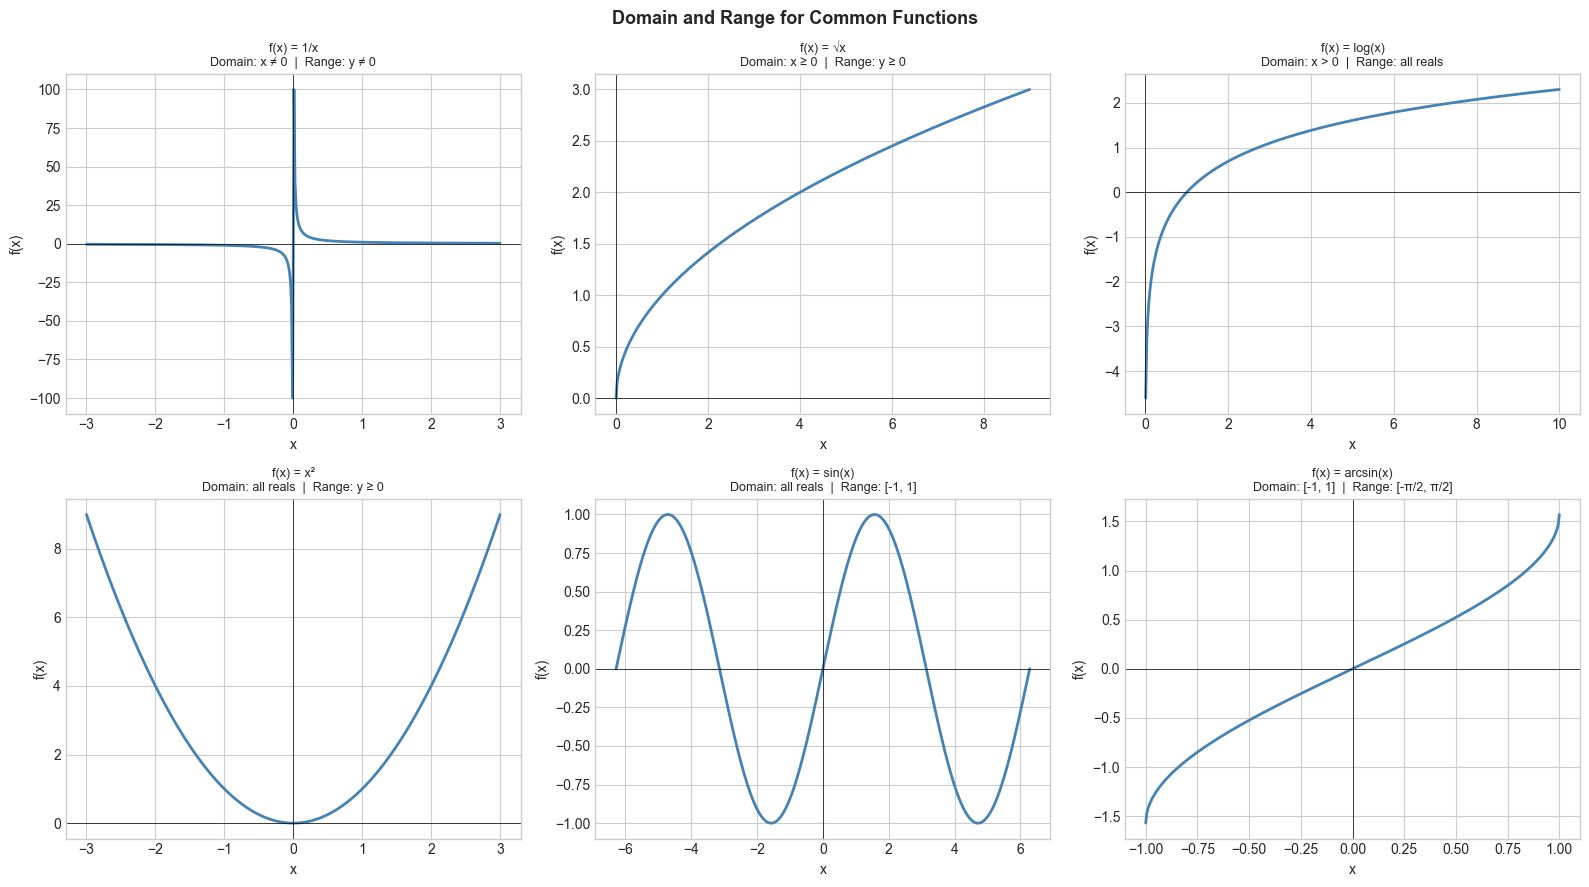

In [1]:
# --- Visualization: Domain restrictions for common functions ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

functions = [
    # (name, domain_range, fn, domain_label, range_label)
    ('f(x) = 1/x',  np.concatenate([np.linspace(-3, -0.01, 200), np.linspace(0.01, 3, 200)]),
     lambda x: 1/x, 'x ≠ 0', 'y ≠ 0'),
    ('f(x) = √x',   np.linspace(0, 9, 400),
     np.sqrt, 'x ≥ 0', 'y ≥ 0'),
    ('f(x) = log(x)', np.linspace(0.01, 10, 400),
     np.log, 'x > 0', 'all reals'),
    ('f(x) = x²',   np.linspace(-3, 3, 400),
     lambda x: x**2, 'all reals', 'y ≥ 0'),
    ('f(x) = sin(x)', np.linspace(-2*np.pi, 2*np.pi, 400),
     np.sin, 'all reals', '[-1, 1]'),
    ('f(x) = arcsin(x)', np.linspace(-1, 1, 400),
     np.arcsin, '[-1, 1]', '[-π/2, π/2]'),
]

for ax, (name, x_vals, fn, dom, rng) in zip(axes.flat, functions):
    y_vals = fn(x_vals)
    ax.plot(x_vals, y_vals, color='steelblue', linewidth=2)
    ax.set_title(f'{name}\nDomain: {dom}  |  Range: {rng}', fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    # Shade the valid domain
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle('Domain and Range for Common Functions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

For a function f : A → B:
- **Domain**: dom(f) = A
- **Codomain**: cod(f) = B
- **Range (image)**: im(f) = {f(x) : x ∈ A} ⊆ B

**Surjective** (onto): im(f) = B — every element of B is hit
**Injective** (one-to-one): f(x₁) = f(x₂) implies x₁ = x₂ — no two inputs share an output
**Bijective**: both injective and surjective — perfect pairing between A and B

These properties determine whether a function has an inverse (ch055).

In [2]:
# --- Mathematical Formulation: Determining range numerically ---
import numpy as np

def numerical_range(f, domain_start, domain_end, n_samples=10000):
    """
    Estimate the range of function f over a domain interval.
    Uses dense sampling — gives approximate min and max of the range.
    
    Args:
        f: callable, function from reals to reals
        domain_start, domain_end: float, domain interval
        n_samples: int, number of sample points
    Returns:
        (min_val, max_val): approximate range bounds
    """
    x = np.linspace(domain_start, domain_end, n_samples)
    y = f(x)
    # Filter out nan/inf (undefined points)
    y_valid = y[np.isfinite(y)]
    if len(y_valid) == 0:
        return None, None
    return y_valid.min(), y_valid.max()

# Test on known functions
test_cases = [
    ('x²  on [-3, 3]',  lambda x: x**2,   -3, 3),
    ('sin(x) on [-2π, 2π]', np.sin,       -2*np.pi, 2*np.pi),
    ('log(x) on [0.01, 10]', np.log,       0.01, 10),
    ('1/x on [0.1, 5]', lambda x: 1/x,    0.1, 5),
]

for name, f, a, b in test_cases:
    lo, hi = numerical_range(f, a, b)
    print(f"Range of {name}: [{lo:.4f}, {hi:.4f}]")

Range of x²  on [-3, 3]: [0.0000, 9.0000]
Range of sin(x) on [-2π, 2π]: [-1.0000, 1.0000]
Range of log(x) on [0.01, 10]: [-4.6052, 2.3026]
Range of 1/x on [0.1, 5]: [0.2000, 10.0000]


---

## 5. Python Implementation

In [3]:
# --- Implementation: Domain-aware function wrapper ---
import numpy as np

class DomainAwareFunction:
    """
    Wraps a mathematical function with explicit domain checking.
    Raises ValueError for inputs outside the domain.
    Provides a safe vectorized apply method.
    """
    
    def __init__(self, f, domain_predicate, name='f', domain_description='unknown'):
        """
        Args:
            f: callable, the underlying function
            domain_predicate: callable, returns True if x is in domain
            name: str, function name for error messages
            domain_description: str, human-readable domain description
        """
        self.f = f
        self.domain_predicate = domain_predicate
        self.name = name
        self.domain_description = domain_description
    
    def __call__(self, x):
        """Apply function, raising ValueError if x is outside domain."""
        x = np.asarray(x, dtype=float)
        valid = self.domain_predicate(x)
        if not np.all(valid):
            bad = x[~valid] if x.ndim > 0 else x
            raise ValueError(
                f"{self.name}: input {bad} outside domain ({self.domain_description})"
            )
        return self.f(x)
    
    def safe_apply(self, x, fill_value=np.nan):
        """Apply function, returning fill_value for out-of-domain inputs."""
        x = np.asarray(x, dtype=float)
        result = np.full_like(x, fill_value)
        valid = self.domain_predicate(x)
        result[valid] = self.f(x[valid])
        return result

# Create domain-aware versions of common functions
sqrt_safe = DomainAwareFunction(
    np.sqrt, lambda x: x >= 0, name='sqrt', domain_description='x >= 0'
)
log_safe = DomainAwareFunction(
    np.log, lambda x: x > 0, name='log', domain_description='x > 0'
)

# Demonstrate safe_apply with mixed valid/invalid inputs
test_inputs = np.array([-4, -1, 0, 1, 4, 9, 16])

print("Input:", test_inputs)
print("sqrt_safe:", sqrt_safe.safe_apply(test_inputs))   # nan for negatives
print("log_safe: ", log_safe.safe_apply(test_inputs))    # nan for non-positives

Input: [-4 -1  0  1  4  9 16]
sqrt_safe: [nan nan  0.  1.  2.  3.  4.]
log_safe:  [       nan        nan        nan 0.         1.38629436 2.19722458
 2.77258872]


---

## 6. Experiments

In [4]:
# --- Experiment 1: What happens when you violate a domain? ---
# Hypothesis: NumPy silently handles domain violations with nan/inf rather than erroring.
# Try: change which function and which values you test.
import numpy as np

print("Domain violations and NumPy's responses:")
print(f"  log(0)    = {np.log(0)}")
print(f"  log(-1)   = {np.log(-1)}")
print(f"  sqrt(-1)  = {np.sqrt(-1)}")
print(f"  1/0       = {1.0/0.0 if False else 'ZeroDivisionError — use np.float64'}")  
print(f"  np.float64(1)/np.float64(0) = {np.float64(1)/np.float64(0)}")
print(f"  arcsin(2) = {np.arcsin(2)}")

# The silent nan/inf is DANGEROUS in ML — it propagates through all downstream ops
x = np.array([1.0, 0.0, -1.0, 4.0])
result = np.log(x)  # produces nan for non-positive values
print("\nlog([1, 0, -1, 4]) =", result)
print("sum =>", np.sum(result))  # NaN poisons everything!
print("\nLesson: always validate domain BEFORE applying the function.")

Domain violations and NumPy's responses:
  log(0)    = -inf
  log(-1)   = nan
  sqrt(-1)  = nan
  1/0       = ZeroDivisionError — use np.float64
  np.float64(1)/np.float64(0) = inf
  arcsin(2) = nan

log([1, 0, -1, 4]) = [0.               -inf        nan 1.38629436]
sum => nan

Lesson: always validate domain BEFORE applying the function.


C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:7: RuntimeWarning: divide by zero encountered in log
  print(f"  log(0)    = {np.log(0)}")
C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:8: RuntimeWarning: invalid value encountered in log
  print(f"  log(-1)   = {np.log(-1)}")
C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:9: RuntimeWarning: invalid value encountered in sqrt
  print(f"  sqrt(-1)  = {np.sqrt(-1)}")
C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  np.float64(1)/np.float64(0) = {np.float64(1)/np.float64(0)}")
C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:12: RuntimeWarning: invalid value encountered in arcsin
  print(f"  arcsin(2) = {np.arcsin(2)}")
C:\Users\user\AppData\Local\Temp\ipykernel_9356\438985284.py:16: RuntimeWarning: divide by zero encountered in log
  result = np.log(x)  # produces nan for non-positive values
C:\Users\

In [5]:
# --- Experiment 2: Injective, surjective, bijective ---
# Hypothesis: We can test these properties numerically for functions on finite sets.
# Try: change the function and the domain size.

import numpy as np

DOMAIN = list(range(1, 8))  # {1, 2, 3, 4, 5, 6, 7}  # <-- try changing this

def test_properties(f, domain, codomain=None):
    """Test injective and surjective properties numerically."""
    outputs = [f(x) for x in domain]
    
    # Injective: all outputs are distinct
    injective = len(outputs) == len(set(outputs))
    
    # Surjective: only testable if codomain is known
    surjective = None
    if codomain is not None:
        surjective = set(outputs) == set(codomain)
    
    return injective, surjective, outputs

# Test several functions
tests = [
    ('x → x² mod 7',  lambda x: (x**2) % 7, None),
    ('x → x mod 7',   lambda x: x % 7,      list(range(7))),
    ('x → 2x mod 7',  lambda x: (2*x) % 7,  list(range(7))),
    ('x → 3x mod 7',  lambda x: (3*x) % 7,  list(range(7))),
]

for name, f, cod in tests:
    inj, surj, out = test_properties(f, DOMAIN, cod)
    print(f"{name}:")
    print(f"  Outputs: {out}")
    print(f"  Injective: {inj}  |  Surjective: {surj}")

x → x² mod 7:
  Outputs: [1, 4, 2, 2, 4, 1, 0]
  Injective: False  |  Surjective: None
x → x mod 7:
  Outputs: [1, 2, 3, 4, 5, 6, 0]
  Injective: True  |  Surjective: True
x → 2x mod 7:
  Outputs: [2, 4, 6, 1, 3, 5, 0]
  Injective: True  |  Surjective: True
x → 3x mod 7:
  Outputs: [3, 6, 2, 5, 1, 4, 0]
  Injective: True  |  Surjective: True


---

## 7. Exercises

**Easy 1.** State the natural domain of each: (a) f(x) = (x-3)/(x²-9) (b) f(x) = log(log(x)) (c) f(x) = √(4-x²). *(Expected: (a) x≠3 and x≠-3, (b) x>1, (c) -2≤x≤2)*

**Easy 2.** For f(x) = x² with domain restricted to [0, 5], what is the range? Verify computationally by generating 10000 uniform random samples in [0,5] and finding the min/max of f(x). *(Expected: [0, 25])*

**Medium 1.** Write a function `find_domain_intervals(f, x_min, x_max, n=10000)` that samples f over [x_min, x_max] and returns a list of contiguous intervals where f is defined (i.e., produces finite values). Test on f(x) = log(x² - 4). *(Hint: find where output is finite, then group contiguous indices)*

**Medium 2.** The function f(x) = x² is not injective over ℝ, but becomes injective if restricted to [0, ∞). Write a function `is_injective_on(f, domain_array, tolerance=1e-9)` and verify this claim. *(Hint: round values to handle floating point)*

**Hard.** For f(x) = sin(x) on [-π/2, π/2], demonstrate numerically that f is both injective and surjective onto [-1, 1] (i.e., bijective). Then show that on [-π, π], f is surjective but not injective. Prove the non-injectivity by finding two distinct x values with the same f(x) value. *(Challenge: what is the minimum domain extension needed to break injectivity?)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Domain Boundary Detector ---
# Problem: Many ML preprocessing functions have hidden domain restrictions.
#          Build a tool that automatically detects where a function fails
#          and visualizes the valid and invalid regions.
# Dataset: Dense sample grid over a range containing edge cases.
# Task: For each test function, detect valid/invalid regions and plot them.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def detect_domain(f, x_min, x_max, n=5000):
    """
    Detect valid (finite) and invalid (nan/inf) input regions.
    Returns x_valid, y_valid, x_invalid.
    """
    x = np.linspace(x_min, x_max, n)
    with np.errstate(divide='ignore', invalid='ignore'):
        y = f(x)
    finite_mask = np.isfinite(y)
    return x[finite_mask], y[finite_mask], x[~finite_mask]

# Test on functions with interesting domain structures
funcs = [
    ('log(x² - 1)',  lambda x: np.log(x**2 - 1),  -3, 3),
    ('sqrt(sin(x))', lambda x: np.sqrt(np.sin(x)), -2*np.pi, 2*np.pi),
    ('1/(x²-3x+2)', lambda x: 1/(x**2 - 3*x + 2), -1, 4),
    ('arcsin(x/2)', lambda x: np.arcsin(x/2),      -3, 3),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, f, a, b) in zip(axes.flat, funcs):
    xv, yv, xi = detect_domain(f, a, b)
    ax.plot(xv, yv, color='steelblue', linewidth=1.5, label='Defined')
    ax.scatter(xi, np.zeros_like(xi), color='crimson', s=2, alpha=0.3, label='Undefined')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'f(x) = {name}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.legend(fontsize=8)

plt.suptitle('Domain Boundary Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What we covered:**
- Domain = valid inputs; Codomain = declared output set; Range = actual outputs produced
- Natural domain is determined by mathematical constraints (no division by zero, no log of negatives)
- NumPy silently produces nan/inf for domain violations — always validate inputs
- Injective (one-to-one) and surjective (onto) describe the input-output coverage properties

**Backward connection:** This makes precise what ch051 left vague — a function needs not just a rule but a set of valid inputs.

**Forward connections:**
- In ch055 (Inverse Functions), we will see that injectivity is exactly the condition needed for an inverse to exist
- Domain restrictions reappear in ch073 (Error and Residuals) — a model's domain must cover all data points
- In ch241 (Probability), sample spaces are the domain of probability functions — same concept, probabilistic setting